Loading datasets...
Training Set Shape: (147613, 51)
Testing Set Shape:  (63267, 51)

Preprocessing, encoding categorical features, and scaling data...
Features after encoding: 64
Applying StandardScaler to normalize feature ranges for SVM calculation...

Treinando classificador binário (SVM Linear)
Fazendo fit no modelo...
Predizendo no conjunto de teste...

--- Relatório - Classe Binária ---
              precision    recall  f1-score   support

  Normal (0)       0.65      0.98      0.78     30351
  Ataque (1)       0.97      0.52      0.67     32916

    accuracy                           0.74     63267
   macro avg       0.81      0.75      0.73     63267
weighted avg       0.82      0.74      0.73     63267



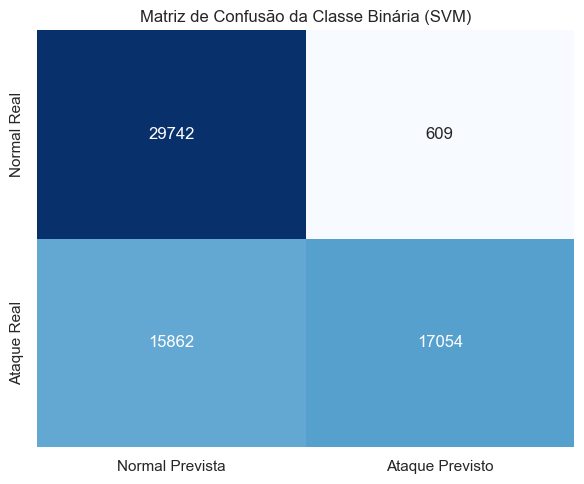

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set visualization style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LOAD DATASETS
# ==========================================
print("Loading datasets...")
train_df = pd.read_csv("ubuntu-server_training-set.csv")
test_df = pd.read_csv("ubuntu-server_testing-set.csv")

print(f"Training Set Shape: {train_df.shape}")
print(f"Testing Set Shape:  {test_df.shape}")

# ==========================================
# 2. DATA PREPROCESSING, ENCODING & SCALING
# ==========================================
print("\nPreprocessing, encoding categorical features, and scaling data...")

# Define targets and the specific network identity/time columns that ML cannot process
targets = ['label', 'attack_cat']
identities = ['id', 'srcip', 'sport', 'dstip', 'dsport', 'stime', 'ltime', 'ct_state_ttl']

# Combine them into a single list of columns to drop safely
drop_cols = targets + identities

# Separate features (X) and targets (y)
X_train = train_df.drop(columns=[col for col in drop_cols if col in train_df.columns])
y_train_bin = train_df['label']
y_train_multi = train_df['attack_cat']

X_test = test_df.drop(columns=[col for col in drop_cols if col in test_df.columns])
y_test_bin = test_df['label']
y_test_multi = test_df['attack_cat']

# Categorical columns to encode
cat_cols = ['proto', 'service', 'state']

# Apply One-Hot Encoding to categorical features
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols)

# Align Train and Test columns (crucial if some categories only exist in one set)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

print(f"Features after encoding: {X_train_encoded.shape[1]}")

# --- NEW FOR SVM: FEATURE SCALING ---
print("Applying StandardScaler to normalize feature ranges for SVM calculation...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# ==========================================
# 3. BINARY CLASSIFICATION (Attack vs Normal)
# ==========================================
print("\n" + "="*50)
print("Treinando classificador binário (SVM Linear)")
print("="*50)

# Initialize LinearSVC with balanced class weights
# dual="auto" is recommended for large samples in newer sklearn versions
svm_bin = LinearSVC(
    class_weight='balanced', 
    random_state=42,
    dual="auto",
    max_iter=2000 # Increased max iterations to ensure convergence
)

print("Fazendo fit no modelo...")
svm_bin.fit(X_train_scaled, y_train_bin)

print("Predizendo no conjunto de teste...")
y_pred_bin = svm_bin.predict(X_test_scaled)

# Binary Metrics
print("\n--- Relatório - Classe Binária ---")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Normal (0)', 'Ataque (1)']))

# Binary Confusion Matrix
plt.figure(figsize=(6, 5))
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal Prevista', 'Ataque Previsto'],
            yticklabels=['Normal Real', 'Ataque Real'])
plt.title('Matriz de Confusão da Classe Binária (SVM)')
plt.tight_layout()
plt.show()




Treinando o Classificador Multi-Classe (Attack_Cat - SVM Linear)
Fazendo fit no modelo...
Predizendo no conjunto de teste...

--- Relatório - Multiclasse ---
                precision    recall  f1-score   support

      Analysis       0.15      0.07      0.10      3990
           DoS       1.00      1.00      1.00     11847
      Exploits       0.94      0.15      0.26      8192
       Fuzzers       0.18      0.20      0.19      4085
        Normal       0.67      0.89      0.76     30351
Reconnaissance       0.90      0.66      0.76      4802

      accuracy                           0.70     63267
     macro avg       0.64      0.49      0.51     63267
  weighted avg       0.72      0.70      0.66     63267



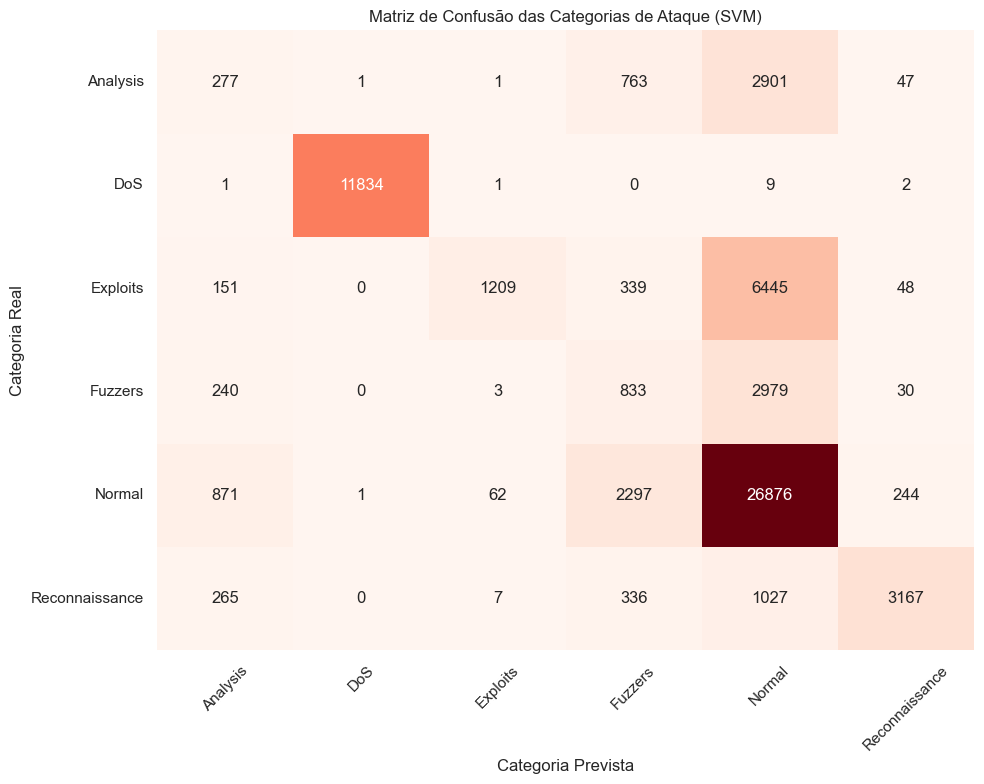


Top 10 Features Mais Importantes (Baseado nos Coeficientes SVM)
         Feature  Importancia
           dpkts     2.089833
           spkts     1.455943
     trans_depth     1.434903
ct_flw_http_mthd     1.306282
      ct_src_ltm     0.747392
           sload     0.711988
  ct_dst_src_ltm     0.673549
       state_REQ     0.556436
            swin     0.446480
       state_FIN     0.366312


In [2]:
# ==========================================
# 4. MULTI-CLASS CLASSIFICATION (Attack Categories)
# ==========================================
print("\n" + "="*50)
print("Treinando o Classificador Multi-Classe (Attack_Cat - SVM Linear)")
print("="*50)

# Initialize a new LinearSVC for multi-class
svm_multi = LinearSVC(
    class_weight='balanced', 
    random_state=42,
    dual="auto",
    max_iter=5000
)

print("Fazendo fit no modelo...")
svm_multi.fit(X_train_scaled, y_train_multi)

print("Predizendo no conjunto de teste...")
y_pred_multi = svm_multi.predict(X_test_scaled)

# Multi-Class Metrics
print("\n--- Relatório - Multiclasse ---")
print(classification_report(y_test_multi, y_pred_multi))

# Multi-Class Confusion Matrix
plt.figure(figsize=(10, 8))
cm_multi = confusion_matrix(y_test_multi, y_pred_multi)

# Get unique classes present in the test set to label the axes correctly
labels = sorted(y_test_multi.unique())

sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusão das Categorias de Ataque (SVM)')
plt.xlabel('Categoria Prevista')
plt.ylabel('Categoria Real')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# 5. FEATURE IMPORTANCE (Coefficients)
# ==========================================
print("\n" + "="*50)
print("Top 10 Features Mais Importantes (Baseado nos Coeficientes SVM)")
print("="*50)

# For multi-class One-vs-Rest LinearSVC, the shape of coef_ is (n_classes, n_features)
# We take the mean of the absolute coefficients across all classes to find the globally most impactful features
global_importances = np.mean(np.abs(svm_multi.coef_), axis=0)

feature_importances = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Importancia': global_importances
}).sort_values(by='Importancia', ascending=False)

print(feature_importances.head(10).to_string(index=False))